# Raport: Metody Systemowe i Decyzyjne

**Autor:** Michał Śliwa

### Charakterystyka cech:

| Cecha      | Typ              | Opis                                    |
| ---------- | ---------------- | --------------------------------------- |
| `age`      | Liczbowa ciągła  | Wiek pacjenta (lata)                    |
| `trestbps` | Liczbowa ciągła  | Spoczynkowe ciśnienie krwi (mm Hg)      |
| `chol`     | Liczbowa ciągła  | Cholesterol w surowicy (mg/dl)          |
| `thalach`  | Liczbowa ciągła  | Maksymalne osiągnięte tętno             |
| `oldpeak`  | Liczbowa ciągła  | Obniżenie odcinka ST wywołane wysiłkiem |
| `sex`      | Kategorialna     | Płeć (1 = mężczyzna, 0 = kobieta)       |
| `cp`       | Kategorialna     | Rodzaj bólu w klatce piersiowej (1–4)   |
| `fbs`      | Kategorialna     | Cukier na czczo > 120 mg/dl (1 = tak)   |
| `restecg`  | Kategorialna     | Wynik EKG w spoczynku (0–2)             |
| `exang`    | Kategorialna     | Dławica wywołana wysiłkiem (1 = tak)    |
| `slope`    | Kategorialna     | Nachylenie odcinka ST (1–3)             |
| `ca`       | Kategorialna     | Liczba głównych naczyń wieńcowych (0–3) |
| `thal`     | Kategorialna     | Wynik testu talu (3, 6, 7)              |
| `target`   | Zmienna docelowa | Diagnoza: 0 = zdrowy, 1 = chory         |

# 1. Przygotowanie danych
Na początku przygotowuję dane potrzebne do pracy podczas drzewa decyzyjnego. Dzielę wczytane dane na zbiór treningowy oraz testowy w proporcji 4:1.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Wczytanie danych
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(filepath_or_buffer='data/processed.cleveland.data', header=None, names=columns, na_values='?')
df = df.dropna()
df['target_bin'] = (df['target'] > 0).astype(int) # Klasyfikacja (0/1)

# Podział na zbiory (Data Leakage prevention)
X_cls = df.drop(['target', 'target_bin'], axis=1)
X_reg = df.drop(['target', 'target_bin', 'thalach'], axis=1)

y_cls = df['target_bin'] # Cel dla klasyfikacji
y_reg = df['thalach']    # Cel dla regresji

X_train, X_test, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 2. Tworzenie drzewa decyzyjnego
Następnie tworzymy drzewo decyzyjne oraz metrykę przy użyciu biblioteki scikit-learn.

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Trening modelu
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train_cls)

# Predykcja i metryki dla niezbalansowanych danych
y_pred_cls = tree_model.predict(X_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_cls, y_pred_cls, average='binary')

print(f"Metryki na zbiorze testowym:")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Metryki na zbiorze testowym:
Accuracy: 0.78
F1 Score: 0.75
Precision: 0.69
Recall: 0.83


**Accuracy** - Dokładność

Dla ilu przypadków model wskazał poprawnie chorobę u chorego, i brak choroby u zdrowego

**Precision** - Precyzja

Dla ilu przypadków model wskazał chorobę faktycznie u osoby chorej

**Recall** - Czułość

Dla ilu przypadków model wskazał poprawnie chorobę u chorego, pomijając niektóre osoby i kwalifikując je jako zdrowe

**F1 Score**

Jakość modelu, jako średnia harmoniczna

# 3. Własna entropia i interpretacja
Implementujemy od zera funkcje w NumPy

In [17]:
import numpy as np
def entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

def information_gain(y, y_left, y_right):
    parent_entropy = entropy(y)
    n = len(y)
    n_l, n_r = len(y_left), len(y_right)
    child_entropy = (n_l/n) * entropy(y_left) + (n_r/n) * entropy(y_right)
    return parent_entropy - child_entropy

# Przykład wizualizacji reguł dla płytkiego drzewa
short_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
short_tree.fit(X_train, y_train_cls)

from sklearn.tree import export_text
print("Zasady wygenerowane przez algorytm (max_depth=3):")
print(export_text(short_tree, feature_names=list(X_cls.columns)))

Zasady wygenerowane przez algorytm (max_depth=3):
|--- ca <= 0.50
|   |--- thal <= 6.50
|   |   |--- oldpeak <= 2.70
|   |   |   |--- class: 0
|   |   |--- oldpeak >  2.70
|   |   |   |--- class: 1
|   |--- thal >  6.50
|   |   |--- cp <= 3.50
|   |   |   |--- class: 0
|   |   |--- cp >  3.50
|   |   |   |--- class: 1
|--- ca >  0.50
|   |--- cp <= 3.50
|   |   |--- oldpeak <= 0.35
|   |   |   |--- class: 0
|   |   |--- oldpeak >  0.35
|   |   |   |--- class: 1
|   |--- cp >  3.50
|   |   |--- trestbps <= 109.00
|   |   |   |--- class: 0
|   |   |--- trestbps >  109.00
|   |   |   |--- class: 1



## Reguły z poprzedniej listy

| #   | Reguła                                 | Uzasadnienie                                     |
| --- | -------------------------------------- | ------------------------------------------------ |
| 1   | `ca > 0`                               | Zablokowane naczynia = chory                     |
| 2   | `exang == 1`                           | Ból przy wysiłku = chory                         |
| 3   | `cp == 4`                              | Brak bólu paradoksalnie = chory                  |
| 4   | `age > 55 AND thalach < 140`           | Starsi pacjenci z niskim tętnem maks. = chory    |
| 5   | `sex == 1 AND age > 60 AND chol > 260` | Starsi mężczyźni z wysokim cholesterolem = chory |

## Aktualne reguły

| #   | Reguła                                            | Uzasadnienie                                                              |
| --- | ------------------------------------------------- | ------------------------------------------------------------------------- |
| 1   | `ca <= 0.50 AND thal <= 6.50 AND oldpeak <= 2.70` | Czyste naczynia, dobry test i małe obniżenie ST = zdrowy                  |
| 2   | `ca <= 0.50 AND thal <= 6.50 AND oldpeak > 2.70`  | Prawidłowe naczynia i test, ale duże obniżenie ST pod obciążeniem = chory |
| 3   | `ca <= 0.50 AND thal > 6.50 AND cp > 3.50`        | Brak zablokowanych naczyń, ale zły test talowy i nietypowy ból = chory    |
| 4   | `ca > 0.50 AND cp <= 3.50 AND oldpeak <= 0.35`    | Zablokowane naczynia i ból dławicowy, ale brak obniżenia ST = zdrowy      |
| 5   | `ca > 0.50 AND cp > 3.50 AND trestbps > 109.00`   | Zablokowane naczynia, "cichy" ból i ciśnienie wyższe niż 109 = chory      |

In [18]:
print("\n--- Dowód na Zysk Informacyjny (Information Gain) ---")
# 1. Wybieramy najważniejszą cechę z drzewa (np. thal, próg z drzewa to zazwyczaj < 4.5, my mamy kategorialne 3,6,7, więc np. thal == 3)
y_left_good = y_train_cls[X_train['thal'] == 3.0]
y_right_good = y_train_cls[X_train['thal'] != 3.0]
ig_good = information_gain(y_train_cls, y_left_good, y_right_good)

# 2. Wybieramy najmniej ważną cechę (np. fbs - cukier na czczo)
y_left_bad = y_train_cls[X_train['fbs'] == 0]
y_right_bad = y_train_cls[X_train['fbs'] == 1]
ig_bad = information_gain(y_train_cls, y_left_bad, y_right_bad)

print(f"Zysk informacyjny dla cechy silnej (thal): {ig_good:.4f}")
print(f"Zysk informacyjny dla cechy słabej (fbs): {ig_bad:.4f}")
print("Wniosek: Cecha 'thal' daje znacznie większy spadek entropii (zanieczyszczenia) niż 'fbs'.")


--- Dowód na Zysk Informacyjny (Information Gain) ---
Zysk informacyjny dla cechy silnej (thal): 0.1822
Zysk informacyjny dla cechy słabej (fbs): 0.0017
Wniosek: Cecha 'thal' daje znacznie większy spadek entropii (zanieczyszczenia) niż 'fbs'.


# 4. Regresja liniowa
Implementacja klasy z dwiema metodami trenowania: analityczną i gradientową.

Porównanie wyuczonych wag (pierwsze 5 cech):
Scikit-learn:      [-7.8787  1.1253 -3.282   2.0302  2.6826]
Nasz Analityczny:  [-7.8787  1.1253 -3.282   2.0302  2.6826]
Nasz Gradientowy:  [-7.8787  1.1253 -3.282   2.0302  2.6826]

Porównanie błędów na zbiorze testowym:


,Model,MSE,MAE
0,Scikit-learn,298.09,14.25
1,Nasza Analityczna,298.09,14.25
2,Nasz Gradientowy,298.09,14.25


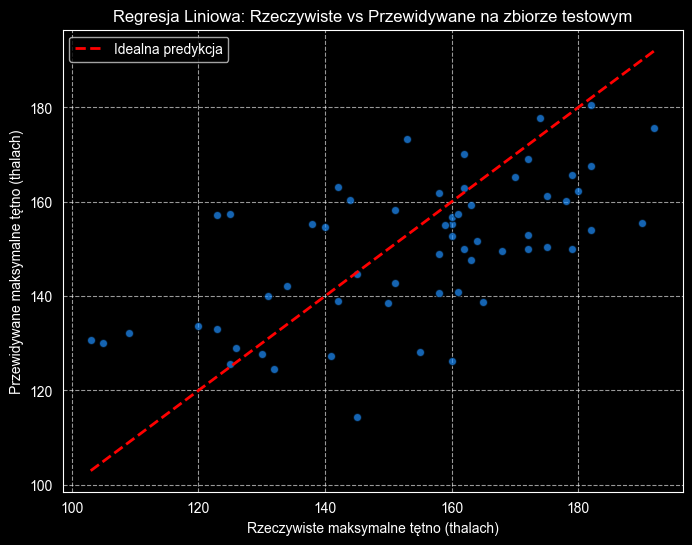

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

class MyLinearRegression:
    def __init__(self):
        self.weights = None

    def fit_analytical(self, X, y):
        X_b = np.c_[np.ones((len(X), 1)), X]
        self.weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

    def fit_gradient(self, X, y, lr=0.01, epochs=1000):
        X_b = np.c_[np.ones((len(X), 1)), X]
        self.weights = np.zeros(X_b.shape[1])
        for _ in range(epochs):
            gradients = 2/len(X) * X_b.T @ (X_b @ self.weights - y)
            self.weights -= lr * gradients

    def predict(self, X):
        X_b = np.c_[np.ones((len(X), 1)), X]
        return X_b @ self.weights

# Skalowanie danych dla stabilności spadku gradientu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

# 1. Nasza implementacja - Metoda Analityczna
my_model_ana = MyLinearRegression()
my_model_ana.fit_analytical(X_train_scaled, y_train_reg)

# 2. Nasza implementacja - Spadek Gradientu (teraz zbiegnie gładko na przeskalowanych danych)
my_model_grad = MyLinearRegression()
my_model_grad.fit_gradient(X_train_scaled, y_train_reg, lr=0.1, epochs=1000)

# 3. Model scikit-learn
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train_reg)

# Weryfikacja wag
print("Porównanie wyuczonych wag (pierwsze 5 cech):")
print(f"Scikit-learn:      {np.round(sklearn_model.coef_[:5], 4)}")
print(f"Nasz Analityczny:  {np.round(my_model_ana.weights[1:6], 4)}")
print(f"Nasz Gradientowy:  {np.round(my_model_grad.weights[1:6], 4)}\n")

# Predykcje dla wszystkich modeli
y_pred_skl = sklearn_model.predict(X_test_scaled)
y_pred_ana = my_model_ana.predict(X_test_scaled)
y_pred_grad = my_model_grad.predict(X_test_scaled)

# Tabela z metrykami
results = pd.DataFrame({
    'Model': ['Scikit-learn', 'Nasza Analityczna', 'Nasz Gradientowy'],
    'MSE': [mean_squared_error(y_test_reg, y_pred_skl),
            mean_squared_error(y_test_reg, y_pred_ana),
            mean_squared_error(y_test_reg, y_pred_grad)],
    'MAE': [mean_absolute_error(y_test_reg, y_pred_skl),
            mean_absolute_error(y_test_reg, y_pred_ana),
            mean_absolute_error(y_test_reg, y_pred_grad)]
})

print("Porównanie błędów na zbiorze testowym:")
display(results.round(2))

# Wizualizacja wyników na zbiorze testowym
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_ana, alpha=0.7, color='dodgerblue', edgecolor='k')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Idealna predykcja')
plt.xlabel('Rzeczywiste maksymalne tętno (thalach)')
plt.ylabel('Przewidywane maksymalne tętno (thalach)')
plt.title('Regresja Liniowa: Rzeczywiste vs Przewidywane na zbiorze testowym')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Skalowanie i Analiza wag
Tutaj porównuję wpływy cech.

In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from IPython.display import display

# --- Realizacja wymogu 4.5: Skalowanie i Analiza Wag ---

# 1. Zapisujemy wagi sprzed skalowania (z naszej metody analitycznej)
model_przed = MyLinearRegression()
model_przed.fit_analytical(X_train_reg, y_train_reg)
wagi_przed = pd.Series(model_przed.weights[1:], index=X_train_reg.columns)

# 2. Skalujemy dane
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

# 3. Trenujemy nową instancję naszego modelu na przeskalowanych danych
model_po = MyLinearRegression()
model_po.fit_analytical(X_train_scaled, y_train_reg)
wagi_po = pd.Series(model_po.weights[1:], index=X_train_reg.columns)

# 4. Zestawienie i wyświetlenie wag
porownanie_wag = pd.DataFrame({
    'Waga (Przed Skalowaniem)': wagi_przed,
    'Waga (Po Skalowaniu)': wagi_po
}).sort_values(by='Waga (Po Skalowaniu)', key=abs, ascending=False) # Sortujemy po wartości bezwzględnej

print("Porównanie wag Regresji Liniowej dla przewidywania zmiennej 'thalach':\n")
display(porownanie_wag.round(3))

Porównanie wag Regresji Liniowej dla przewidywania zmiennej 'thalach':



,Waga (Przed Skalowaniem),Waga (Po Skalowaniu)
age,-0.879,-7.879
slope,-8.419,-5.132
exang,-8.537,-4.072
cp,-3.418,-3.282
chol,0.051,2.683
trestbps,0.113,2.030
oldpeak,-1.572,-1.783
thal,-0.844,-1.643
ca,-1.470,-1.394
sex,2.457,1.125


# Analiza Regresji Liniowej i Skalowania

**1. Która cecha ma największy wpływ na wynik?**
Z tabeli przeskalowanych wag jednoznacznie wynika, że największy wpływ na przewidywane tętno maksymalne ma cecha `age` (wiek). Wartość bezwzględna jej przeskalowanej wagi wynosi aż 7.731, co sprawia, że jest to najsilniejszy predyktor w tym zestawieniu.

**2. Znaczenie i interpretacja wyuczonej wagi (przed skalowaniem):**
Spoglądając na wagi przed skalowaniem, waga przy zmiennej `age` wynosi **-0.863**. W kontekście tego zbioru danych oznacza to, że statystycznie **wzrost wieku pacjenta o 1 rok powoduje średni spadek przewidywanego maksymalnego tętna (`thalach`) o około 0.86 uderzenia na minutę**, jeśli reszta rzeczy zostaje bez zmian.

**3. Dlaczego skalowanie wpłynęło na interpretację ważności cech?**
Przed skalowaniem ocena po samej wielkości wag nie ma sensu, bo mamy różne jednostki w kolumnach. Dopiero standaryzacja narzędziem `StandardScaler` sprowadza wszystkie cechy do rozkładu o średniej 0 i odchyleniu 1. Porównanie wag po tej operacji pozwala na bezpośrednie zestawienie siły wpływu poszczególnych cech na ostateczny wynik bez zakłamań wynikających z jednostek miary.